In [86]:
import os
from typing import Dict, List, Tuple, Any, TypedDict, Annotated
from datetime import datetime
import random
import tempfile
import subprocess
import uuid

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, END, START
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate
import json

def get_api_key_from_file(file_path: str, default_key: str) -> str:
    try:
        data = json.load(open(file_path))
        return data["anthropic_api_key"]
    except FileNotFoundError:
        return default_key
# Type definitions for our state


class FileContent(TypedDict):
    path: str
    content: str


class ErrorChange(TypedDict):
    line_number: int
    original_code: str
    modified_code: str
    

class ErrorDetail(TypedDict):
    file_path: str
    error_type: str
    description: str
    changes: List[ErrorChange]


class GraphState(TypedDict):
    repo_path: str
    main_branch: str
    files: List[str]
    selected_files: List[str]
    error: ErrorDetail
    current_file: FileContent
    error_branch_prefix: str
    ci_command: List[str]
    counter: int = 0
    ci_failed: bool = False


# Initialize LLM
llm = ChatAnthropic(
    model="claude-3-5-sonnet-20240620",
    anthropic_api_key=get_api_key_from_file("api_key.json", os.getenv("ANTHROPIC_API_KEY")),
    temperature=0.2
)

# Set up JSON parser
json_parser = JsonOutputParser()

# Step 1: Initialize the repository analysis


def init_repo_analysis(state: GraphState) -> GraphState:
    """Initialize the repository analysis by scanning files."""
    repo_path = state["repo_path"]
    main_branch = state["main_branch"]
    files = []

    subprocess.run(
        ["git", "show-ref", "--quiet", f"refs/heads/{main_branch}"],
        cwd=repo_path,
        check=True
    )
    subprocess.run(
        ["git", "checkout", main_branch],
        cwd=repo_path,
        check=True
    )
    subprocess.run(
        ["git", "reset", "--hard", main_branch],
        cwd=repo_path,
        check=True
    )
    for root, _, filenames in os.walk(repo_path):
        for filename in filenames:
            if filename.endswith(('.py', '.js', '.ts', '.java', '.cpp', '.c')):
                file_path = os.path.join(root, filename)
                relative_path = os.path.relpath(file_path, repo_path)

                # Skip files in .git, node_modules, etc.
                if any(part.startswith('.') or part == 'node_modules' for part in relative_path.split(os.sep)):
                    continue

                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        lines = f.readlines()
                        if len(lines) < 5:
                            continue
                        files.append(file_path)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

    return {**state, "files": files}


def find_substring_line_numbers(file_path, substring):
    line_numbers = []
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line_num, line in enumerate(file, 1):
                if substring in line:
                    line_numbers.append(line_num)
        
        return line_numbers
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return []
    except Exception as e:
        print(f"Error: {str(e)}")
        return []

def find_closest_line(line_numbers, target, eps=10) -> int:
    for line_number in line_numbers:
        if abs(line_number - target) < eps:
            return line_number
    return line_numbers[0]


def select_files_for_errors(state: GraphState) -> GraphState:
    """Select a subset of files to inject errors into."""
    files = state["files"]
    # Randomly select up to 3 files or 10% of the files, whichever is greater
    num_files_to_select = max(3, int(len(files) * 0.2))
    selected_indices = random.sample(
        range(len(files)), min(num_files_to_select, len(files)))
    selected_files = [files[i] for i in selected_indices]
    
    print("Here are the files to inject errors into:")
    for file in selected_files:
        print(file)

    return {**state, "selected_files": selected_files}



def pick_file(state: GraphState) -> GraphState:
    """Analyze the current file to find potential error injection points."""
    current_file = state["selected_files"][0]
    updated_selected_files = state["selected_files"][1:]

    return {
        **state,
        "current_file": current_file,
        "selected_files": updated_selected_files,
    }



def suggest_errors(state: GraphState) -> GraphState:
    """Use LLM to suggest errors that could be injected into the code."""
    current_file = state["current_file"]
    repo_path = state["repo_path"]
    rel_path = os.path.relpath(current_file, repo_path)
    content = open(current_file, "r").read()
    from sme_agent.code_analyzer import CodeStructureAnalyzer
    analyzer = CodeStructureAnalyzer()
    _current_file = "../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/Controller.java"
    data = analyzer.analyze_directory(repo_path)
    references = []
    
    for collection in data["class_data"]:
        if collection["file_path"] == current_file:
            for item in collection["method_declarations"]:
                references.extend(item.get("references", []))
    for collection in data["functions_data"]:
        if collection["file_path"] == current_file:
            for item in collection["references"]:
                references.extend(item.get("references", []))
    
    raise Exception(references)
    #for collection in [class_data, functions_data, imports_data]:
    #    for item in collection:
    #        raise Exception(item.keys())
    #        references.append(item["references"])
    #
    
    raise Exception("Not implemented")
    
    # Prompt template for error suggestion
    suggest_errors_prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content="""
        You are an expert code analyst tasked with identifying places to inject realistic bugs into code for testing purposes.
        Your goal is to introduce subtle errors that could realistically occur during development. 
        Your error will be used to test incident response system.
        
        Types of errors to consider:
        1. Logic errors (incorrect conditionals, off-by-one errors)
        2. Variable scope issues
        3. API call errors, e.g. wrong parameters, wrong API call, etc.
        4. Error handling problems
        5. Missing edge case handling
        6. Type conversion issues
        7. Resource leaks
        8. Performance issues
        9. Resource exhaustion
        10. Exception during execution
        11. Unexpected behavior
        
        
        For each suggested error, provide:
        - Line number to modify
        - Original code snippet
        - Modified code snippet with error
        - Error type
        - Brief description of the error and its potential impact
        
        Requirements for error:
        - The error should not break compilation
        - The error should cause problems during runtime (e.g. crash, wrong result, etc.)
        
        Format your response as JSON with this structure:
        {
            "error_type": "<error_type>",
            "description": "<description of error and impact>",
            "changes": [
                {
                    "line_number": <int>,
                    "original_code": "<original code snippet>",
                    "modified_code": "<modified code with error>",
                }
            ]
        }
        Respond only with the JSON response, no other text or comments.
        """),
        HumanMessage(content=f"""
        Please analyze this code from file {rel_path} and suggest bug to inject:
        
        ```
        {content}
        ```
        """)
    ])

    # Get suggestions from LLM
    chain = suggest_errors_prompt | llm | json_parser
    error = chain.invoke({})

    # Create error details
    new_error = {
        "file_path": rel_path,
        "error_type": error["error_type"],
        "description": error["description"],
        "changes": error["changes"]
    }
    for change in new_error["changes"]:
        print(f"Finding closest line for {change['original_code']} in {current_file}, {change['line_number']}")
        print(find_substring_line_numbers(current_file, change["original_code"]))
        change["line_number"] = find_closest_line(
            find_substring_line_numbers(current_file, change["original_code"]),
            change["line_number"]
        )

    return {**state, "error": new_error}

# Step 5: Inject errors into the code


def inject_errors(state: GraphState) -> GraphState:
    """Inject the suggested errors into the file."""
    current_error = state["error"]
    current_file = state["current_file"]
    
    file_content = open(current_file, "r").read()
    lines = file_content.split('\n')

    # Sort errors by line number in descending order to avoid offsets
    sorted_changes = sorted(current_error["changes"], key=lambda e: e["line_number"], reverse=True)

    for error in sorted_changes:
        print(f"Injecting error: {error}")
        line_num = error["line_number"] - 1  # Adjust for 0-indexing
        if 0 <= line_num < len(lines):
            # Replace the line with the modified code
            lines[line_num] = lines[line_num].replace(error["original_code"], error["modified_code"])
            
    # Update the file content in our state
    modified_content = '\n'.join(lines)
    
    with open(current_file, "w") as f:
        f.write(modified_content)
    
    return state

# Step 6: Generate ERROR.md content


def generate_error_md(state: GraphState) -> GraphState:
    """Generate the ERROR.md file documenting all the injected errors."""
    error_md_prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content="""
        Create an ERROR.md file that documents all the errors that were injected into the codebase.
        The documentation should be clear, well-structured, and include all relevant details about each error.
        
        For each error, include:
        1. File path
        2. Line number
        3. Error type
        4. Description of the error
        5. Original code
        6. Modified code with the error
        
        Start with a brief introduction explaining the purpose of this document and when it was generated.
        """),
        HumanMessage(content=f"""
        Generate ERROR.md content for these injected error:
        
        {state["error"]}
        """)
    ])

    # Get ERROR.md content from LLM
    chain = error_md_prompt | llm
    result = chain.invoke({})

    if isinstance(result, AIMessage):
        error_md_content = result.content
    else:
        error_md_content = str(result)
    
    repo_path = state["repo_path"]
    with open(os.path.join(repo_path, "ERROR.md"), "w") as f:
        f.write(error_md_content)

    return state

# Step 7: Commit changes to a new branch


def commit_changes(state: GraphState) -> GraphState:
    """Commit the changes to a new branch in the repository."""
    return state
    error_branch_prefix = state["error_branch_prefix"]
    repo_path = state["repo_path"]
    state["counter"] += 1
    branch_name = f"{error_branch_prefix}-{branch_name}"
    
    current_file = state["current_file"]
    repo_path = state["repo_path"]
    rel_path = os.path.relpath(current_file, repo_path)
    
    cmds = [
        (["git", "-C", repo_path, "checkout", "-b", branch_name], None),
        (["git", "-C", repo_path, "add", "ERROR.md", rel_path], None),
        (["git", "-C", repo_path, "commit", "-m", "Inject errors"], None),
        (["git", "-C", repo_path, "push", "origin", branch_name], None),
        (["gh", "pr", "create", "--base", state["main_branch"], "--head", branch_name, "--title", "Inject errors", "--body", "Inject errors"], repo_path),
        (["git", "-C", repo_path, "checkout", state["main_branch"]], None),
    ]
    
    for cmd, cwd in cmds:
        subprocess.run(cmd, check=True, cwd=cwd)
    return state

def run_ci(state: GraphState) -> GraphState:
    repo_path = state["repo_path"]
    try:
        ci_command = state["ci_command"]
        subprocess.run(ci_command, check=True, cwd=repo_path)
        return {
            **state,
            "ci_failed": False
        }
    except subprocess.CalledProcessError as e:
        return {
            **state,
            "ci_failed": True
        }
    
    
    
def reset_changes(state: GraphState) -> GraphState:
    subprocess.run(
        ["git", "-C", state["repo_path"], "reset", "--hard", state["main_branch"]],
        check=True
    )
    return {
        **state,
    }

In [87]:
from typing import Literal

graph = StateGraph(GraphState)
graph.add_node("init_repo_analysis", init_repo_analysis)
graph.add_node("select_files_for_errors", select_files_for_errors)
graph.add_node("pick_file", pick_file)
graph.add_node("suggest_errors", suggest_errors)
graph.add_node("inject_errors", inject_errors)
graph.add_node("run_ci", run_ci)

graph.add_node("generate_error_md", generate_error_md)
graph.add_node("commit_changes", commit_changes)
graph.add_node("reset_changes", reset_changes)

# Add edges
def check_files_for_errors(state: GraphState) -> Literal["__end__", "suggest_errors"]:
    selected_files = state["selected_files"]
    if not selected_files:
        return "__end__"
    else:
        return "suggest_errors"


def check_ci_status(state: GraphState) -> Literal["generate_error_md", "reset_changes"]:
    ci_failed = state["ci_failed"]
    if ci_failed:
        return "reset_changes"
    else:
        return "generate_error_md"

graph.add_edge(START, "init_repo_analysis")
graph.add_edge("init_repo_analysis", "select_files_for_errors")
graph.add_edge("select_files_for_errors", "pick_file")
graph.add_conditional_edges("pick_file", check_files_for_errors)
graph.add_edge("suggest_errors", "inject_errors")
graph.add_edge("inject_errors", "run_ci")
graph.add_conditional_edges("run_ci", check_ci_status)
graph.add_edge("reset_changes", "pick_file")
graph.add_edge("generate_error_md", "commit_changes")
graph.add_edge("commit_changes", "pick_file")



app = graph.compile()

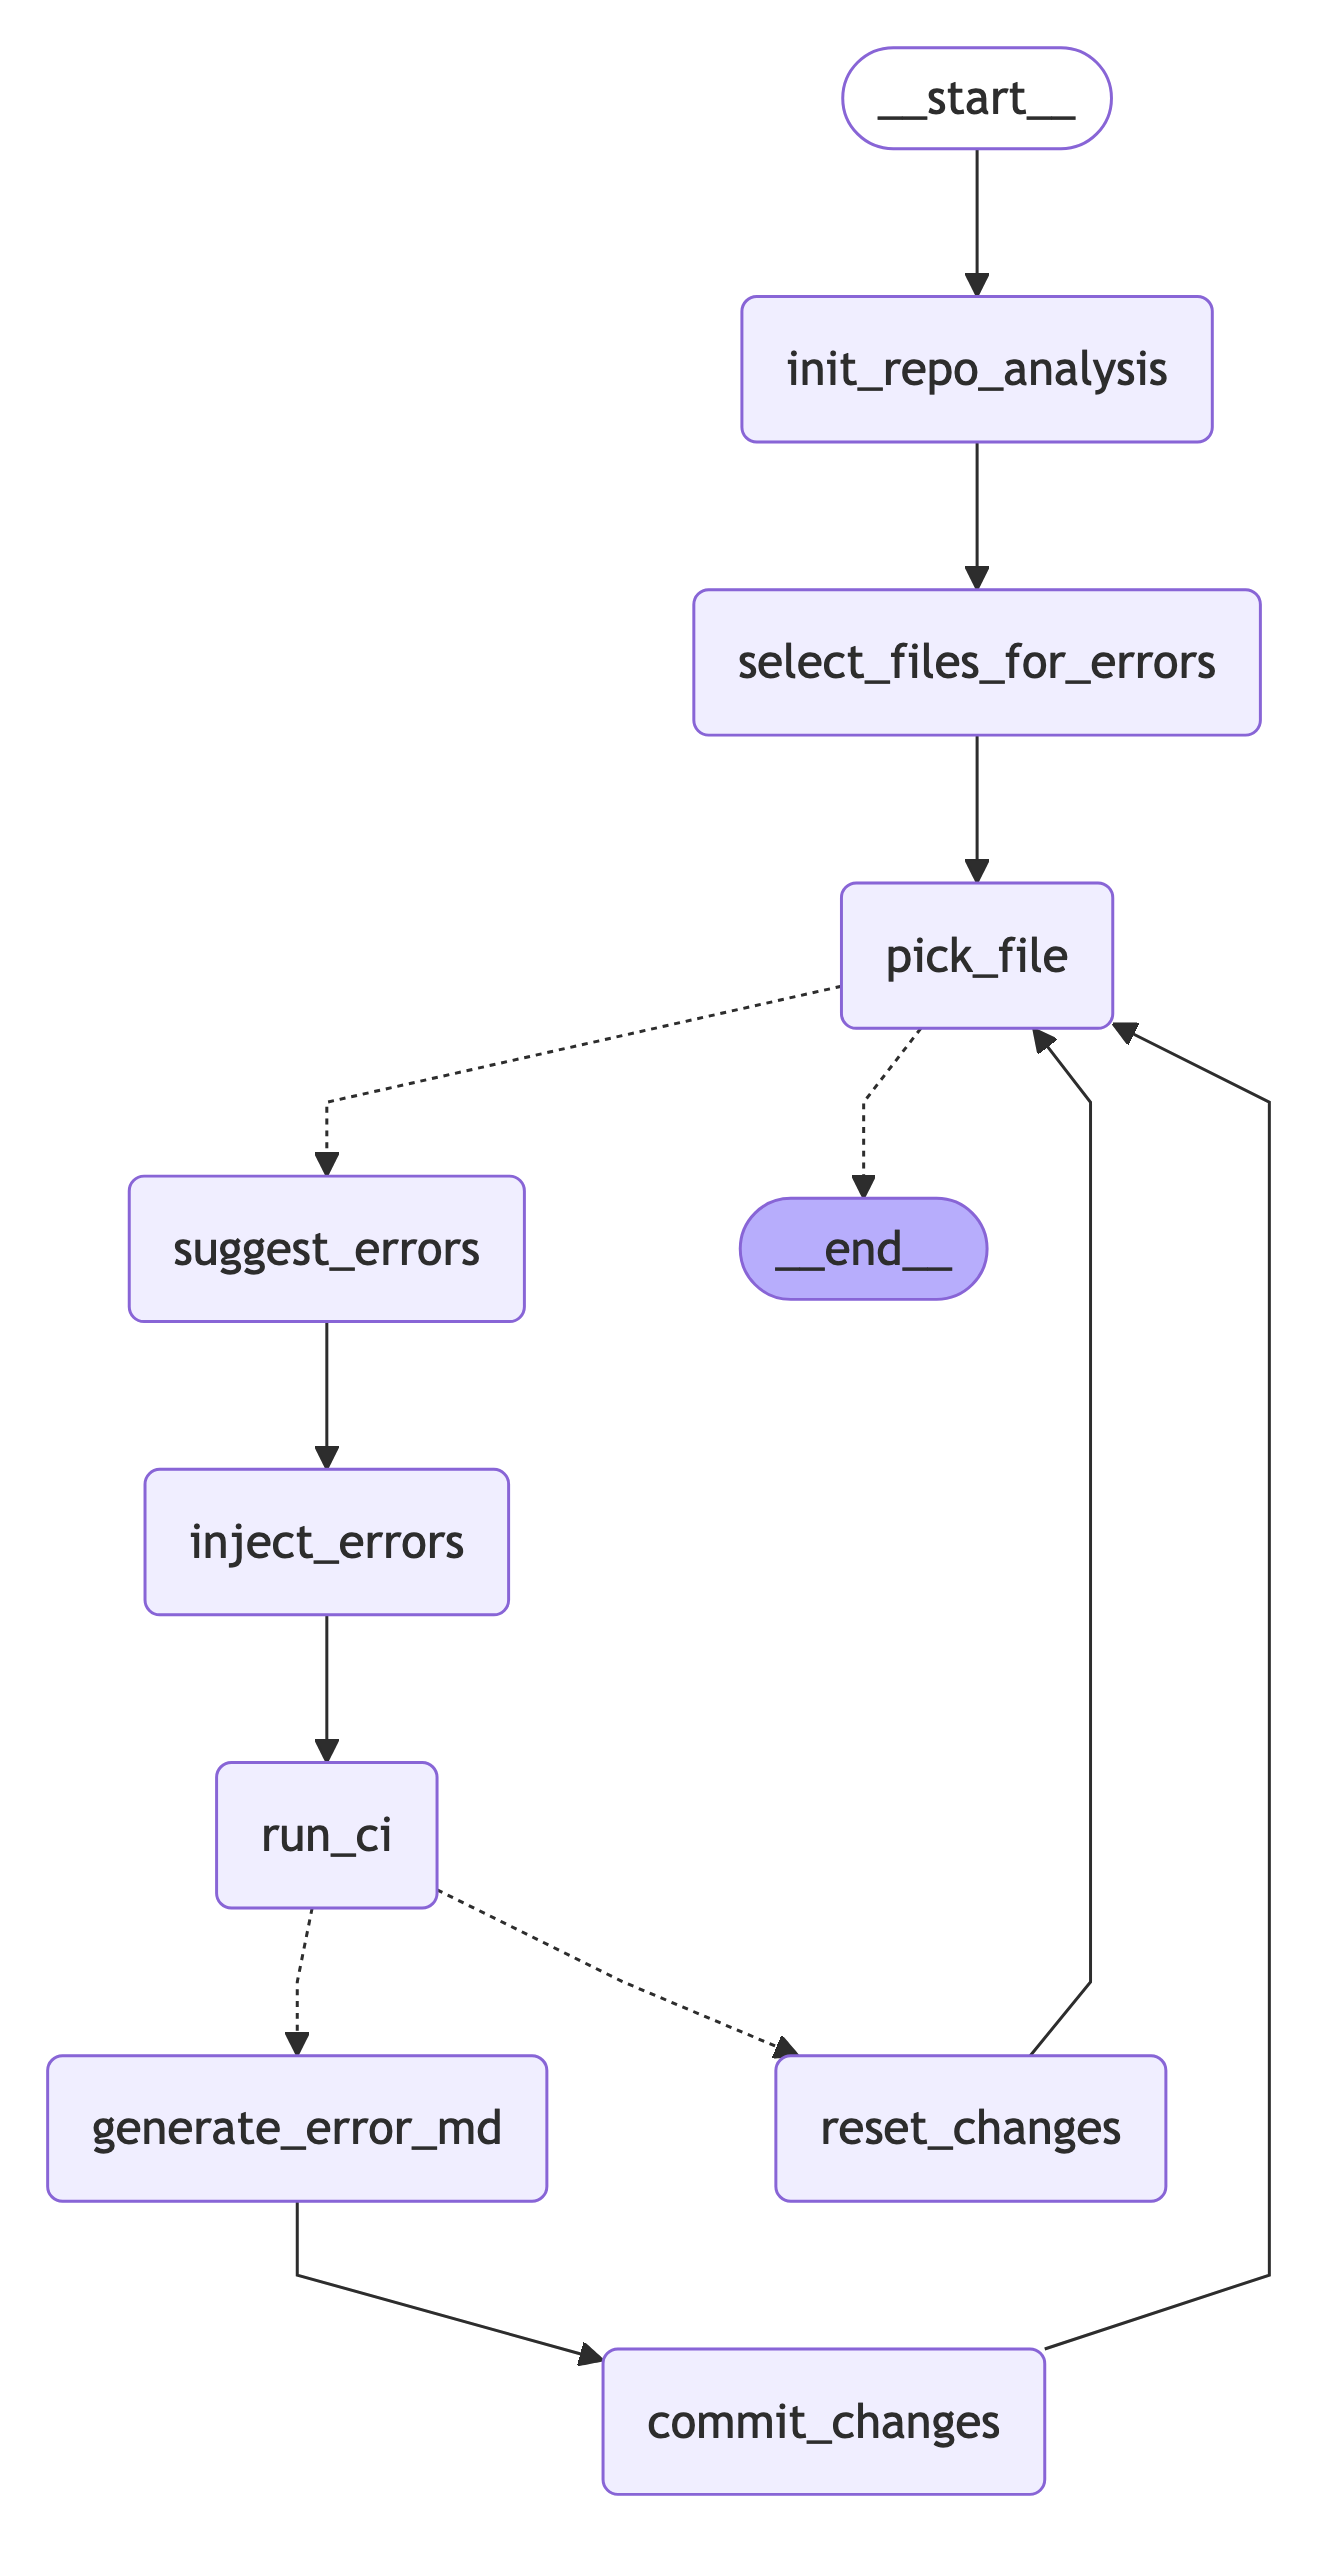

In [88]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles
import nest_asyncio
nest_asyncio.apply()
display(
    Image(
        app.get_graph(xray=True).draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER), width=400
    )
)

In [89]:
initial_state = GraphState(
    repo_path="../services/robot-shop/shipping",
    main_branch="master",
    files=[],
    selected_files=[],
    ci_command=[
        "docker-compose", "-f", "docker-compose.yaml", "build"
    ],
    counter=0,
    error_branch_prefix="error",
)
app.invoke(initial_state)

Your branch is up to date with 'origin/master'.
HEAD is now at 0597719 docs
Here are the files to inject errors into:
../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/CityRepository.java
../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/CodeRepository.java
../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/Calculator.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/CodeRepository.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/RetryableDataSource.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/ShippingServiceApplication.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/Ship.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/Controller.java
Analyzing file: ../services

Already on 'master'


Exception: []

In [17]:


from sme_agent.code_analyzer import CodeStructureAnalyzer

repo_path = "../services/robot-shop/shipping"
analyzer = CodeStructureAnalyzer()
_current_file = "../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/CityRepository.java"
data = analyzer.analyze_directory(repo_path)
references = []

for collection in data["class_data"]:
    if collection["file_path"] == _current_file:
        
        references.extend(collection.get("references", []))
        for item in collection["method_declarations"]:
            references.extend(item.get("references", []))

for collection in data["functions_data"]:
    if collection["file_path"] == _current_file:
        references.extend(collection.get("references", []))
        for item in collection["references"]:
            references.extend(item.get("references", []))

for ref in references:
    print(ref["file_path"])
    print("-"*30)
    lines = open(ref["file_path"]).readlines()
    for line_number in range(ref["start_line"] - 1, ref["end_line"]):
        print(lines[line_number])
    print("-"*30)
    

Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/CodeRepository.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/RetryableDataSource.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/ShippingServiceApplication.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/Ship.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/Controller.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/CityRepository.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/City.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/CartHelper.java
Analyzing file: ../services/robot-shop/shipping/src/main/java/com/instana/robotshop/shipping/Calculator.jav